In [481]:
from pathlib import Path

print(Path().cwd())

/home/gruengroup/christian/Projects/notebook_repository/notebooks/2026-04-24T06-54-05Z


In [172]:
import itertools
import logging
from pathlib import Path
from typing import Any, Callable, Sequence

import matplotlib.pyplot as plt
import mlflow
import nico2_lib as n2l
import numpy as np
import pandas as pd
import plotly.express as px
import polars as pl
import scanpy as sc
import scipy
import seaborn as sns
from experiment import Celltype, Dataset, Model, NumericArray, Result, Sample
from numpy import number
from sqlalchemy import event
from sqlalchemy.engine import Engine
from sqlmodel import Session, create_engine, select
from tqdm import tqdm

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

In [4]:
exp_name = "Default"
benchmark_experiment = mlflow.get_experiment_by_name(exp_name)
if not benchmark_experiment:
    raise ValueError(f"Experiment '{exp_name}' not found.")
runs = mlflow.search_runs(experiment_ids=[benchmark_experiment.experiment_id])
if runs.empty:
    raise RuntimeError(f"No runs found in experiment '{exp_name}'.")
last_run_id = runs.sort_values("start_time", ascending=False)["run_id"].iloc[0]
logger.info(f"Using run_id: {last_run_id}")
logger.info("Downloading 'database.db'...")
database_path = mlflow.artifacts.download_artifacts(
    run_id=last_run_id, artifact_path="database.db"
)
logger.info(f"Local path: {database_path}")
sqlite_url = f"sqlite:///{database_path}"
engine = create_engine(sqlite_url, echo=True)
logger.info("Database engine initialized.")

INFO: Using run_id: a8b4dbb2d8684405a0cef2a77f6b3d54
INFO: Downloading 'database.db'...


INFO: Local path: /tmp/tmpwazm1fkg/database.db
INFO: Database engine initialized.


In [5]:
# database_path = "/Users/egerc/Documents/Projects/notebook_repository/notebooks/2026-03-11T09-44-10Z/database.db"
# database_path = Path().cwd() / "database.db"
logger.info(f"Local path: {database_path}")
sqlite_url = f"sqlite:///{database_path}"
engine = create_engine(sqlite_url, echo=True)
logger.info("Database engine initialized.")

INFO: Local path: /tmp/tmpwazm1fkg/database.db
INFO: Database engine initialized.


## Embedding Feature Autocorrelation

In [6]:
def _create_avg_pairwise_metric_fn(
    metric_fn: Callable[[NumericArray, NumericArray], float],
) -> Callable[[NumericArray], float]:
    def pairwise_metric_fn(
        features: NumericArray,
    ) -> float:
        eps = 1e-8
        return np.array(
            [
                metric_fn(a + eps, b + eps)
                for a, b in itertools.combinations(features.T, 2)
            ]
        ).mean()

    return pairwise_metric_fn


def create_embedding_evaluator(
    correlation_func: Callable[[NumericArray, NumericArray], float],
) -> Callable[[Result], tuple[float, float, float, float]]:
    average_pairwise_correlation_func = _create_avg_pairwise_metric_fn(
        metric_fn=correlation_func
    )

    def pairwise_correlation_func(
        result: Result,
    ) -> tuple[float, float, float, float]:
        results: tuple[float, float, float, float] = tuple(
            [
                average_pairwise_correlation_func(embedding)
                for embedding in [
                    result.global_model_embedding_reference,
                    result.global_model_embedding_query,
                    result.celltype_model_embedding_reference,
                    result.celltype_model_embedding_query,
                ]
            ]
        )
        return results

    return pairwise_correlation_func

## Embedding Structure

In [7]:
def create_embedding_structure_evaluator(
    structure_function: Callable[[NumericArray, NumericArray], float],
) -> Callable[[Result], tuple[float, float, float, float]]:
    def structure_evaluator(
        result: Result,
    ) -> tuple[float, float, float, float]:
        return (
            structure_function(
                result.celltype.reference_adjacency_matrix,
                result.global_model_embedding_reference,
            ),
            structure_function(
                result.celltype.query_adjacency_matrix,
                result.global_model_embedding_query,
            ),
            structure_function(
                result.celltype.reference_adjacency_matrix,
                result.celltype_model_embedding_reference,
            ),
            structure_function(
                result.celltype.query_adjacency_matrix,
                result.celltype_model_embedding_query,
            ),
        )

    return structure_evaluator


def compute_multivariate_geary(
    adjacency: NumericArray,
    embeddings: NumericArray,
) -> float:
    """
    A direct multivariate version of Geary's C.
    Computes Euclidean distance in embedding space weighted by graph adjacency.
    """
    n, d = embeddings.shape
    w_sum = np.sum(adjacency)
    if w_sum == 0:
        return 0.0

    # Variance normalization (denominator)
    # We sum the variance of each feature column
    variance_sum = np.sum(np.var(embeddings, axis=0))
    if variance_sum == 0:
        return 0.0

    # Calculate weighted squared Euclidean distances between all neighbors
    # Using a memory-efficient approach for large n:
    # dist(i,j)^2 = ||xi||^2 + ||xj||^2 - 2<xi, xj>
    norms = np.sum(embeddings**2, axis=1)
    dist_sq = (
        norms[:, np.newaxis]
        + norms[np.newaxis, :]
        - 2 * np.dot(embeddings, embeddings.T)
    )

    numerator = np.sum(adjacency * dist_sq)
    denominator = 2 * w_sum * variance_sum

    return float(((n - 1) * numerator) / (n * denominator))


def blabla(
    func: Callable[[NumericArray, NumericArray], float],
) -> Callable[[NumericArray, NumericArray], float]:
    def blabla2(adjacency: NumericArray, embeddings: NumericArray) -> float:
        # 1. Identify non-zero columns (features)
        # We check if the absolute sum of the column is > 0
        non_zero_mask = np.any(embeddings != 0, axis=0)
        valid_features = embeddings[:, non_zero_mask]

        # 2. Guard against the case where NO features are non-zero
        if valid_features.shape[1] == 0:
            return 0.0

        # 3. Compute only for valid latent features
        scores = [func(adjacency, feature) for feature in valid_features.T]

        return float(np.mean(scores))

    return blabla2


def manual_morans_i(
    adjacency: NumericArray,
    feature: NumericArray,
) -> float:
    """
    Standard Moran's I: I = (n/W) * (z'Wz / z'z)
    Range: [-1, 1]. > 0 is clustered, < 0 is dispersed.
    """
    n = len(feature)
    z = feature - np.mean(feature)
    sum_sq_z = np.sum(z**2)

    if sum_sq_z == 0:
        return 0.0

    w_z = adjacency @ z
    numerator = z @ w_z

    w_sum = np.sum(adjacency)
    if w_sum == 0:
        return 0.0

    return float((n / w_sum) * (numerator / sum_sq_z))

## Cell wise sparsity

In [8]:
def gini(arr: NumericArray) -> float:
    """Compute Gini coefficient of a 1D array."""
    if np.amin(arr) < 0:
        arr -= np.amin(arr)  # Values must be non-negative
    arr = np.sort(arr)
    index = np.arange(1, arr.shape[0] + 1)
    n = arr.shape[0]
    return float((np.sum((2 * index - n - 1) * arr)) / (n * np.sum(arr)))


def entropy(arr: NumericArray) -> float:
    return float(scipy.stats.entropy(arr))


def kurtosis(arr: NumericArray) -> float:
    return float(scipy.stats.kurtosis(arr))


def skew(arr: NumericArray) -> float:
    return float(scipy.stats.skew(arr))


def make_aggregate_cellwise_metric_func(
    func: Callable[[NumericArray], float],
) -> Callable[[NumericArray], float]:
    def aggregate_cellwise_metric_func(arr: NumericArray) -> float:
        return float(np.mean([func(cell) for cell in arr]))

    return aggregate_cellwise_metric_func


def create_embedding_sparsity_evaluator(
    sparsity_func: Callable[[NumericArray], float],
) -> Callable[[Result], tuple[float, float, float, float]]:
    def embedding_sparsity_evaluator(
        result: Result,
    ) -> tuple[float, float, float, float]:
        embedding_sparsity_func = make_aggregate_cellwise_metric_func(
            sparsity_func,
        )
        return (
            embedding_sparsity_func(result.global_model_embedding_reference),
            embedding_sparsity_func(result.global_model_embedding_query),
            embedding_sparsity_func(result.celltype_model_embedding_reference),
            embedding_sparsity_func(result.celltype_model_embedding_query),
        )

    return embedding_sparsity_evaluator

## Coverage sparsity

In [9]:
def make_max_aggregate_featurewise_metric_func(
    func: Callable[[NumericArray], float],
) -> Callable[[NumericArray], float]:

    def aggregate_cellwise_metric_func(arr: NumericArray) -> float:
        return float(func(np.max(arr, axis=1)))

    return aggregate_cellwise_metric_func


def create_coverage_sparsity_evaluator(
    sparsity_func: Callable[[NumericArray], float],
) -> Callable[[Result], tuple[float, float, float, float]]:
    def coverage_sparsity_evaluator(
        result: Result,
    ) -> tuple[float, float, float, float]:
        max_agg_sparsity_func = make_max_aggregate_featurewise_metric_func(
            sparsity_func,
        )
        return (
            max_agg_sparsity_func(result.global_model_embedding_reference),
            max_agg_sparsity_func(result.global_model_embedding_query),
            max_agg_sparsity_func(result.celltype_model_embedding_reference),
            max_agg_sparsity_func(result.celltype_model_embedding_query),
        )

    return coverage_sparsity_evaluator

In [10]:
def identity(x: float) -> float:
    return x


def tent(x: float) -> float:
    return -np.absolute(x)


def negative(x: float) -> float:
    return -x


In [11]:
METRIC_FNS: dict[
    str,
    dict[
        str,
        tuple[
            Callable[[Result], tuple[float, float, float, float]],
            Callable[[float], float],
        ],
    ],
] = {
    "embedding_autocorrelation": {
        "pearsonr": (create_embedding_evaluator(n2l.mt.pearson_metric), tent),
        "spearmanr": (
            create_embedding_evaluator(n2l.mt.spearman_metric),
            tent,
        ),
    },
    "embedding_structure": {
        "multivariate_gearys_c": (
            create_embedding_structure_evaluator(compute_multivariate_geary),
            negative,
        ),
        "morans_i": (
            create_embedding_structure_evaluator(blabla(manual_morans_i)),
            identity,
        ),
    },
    "embedding_sparsity": {
        "gini": (create_embedding_sparsity_evaluator(gini), identity),
        "entropy": (create_embedding_sparsity_evaluator(entropy), negative),
    },
    "coverage_sparsity": {
        "gini": (create_coverage_sparsity_evaluator(gini), negative),
        "entropy": (create_coverage_sparsity_evaluator(entropy), identity),
    },
}

In [12]:
from itertools import product

with Session(engine) as session:
    results = session.exec(select(Result)).all()
    rows: list[dict[str, Any]] = []
    for result in results:
        for metric_category, function_mapping in METRIC_FNS.items():
            for function_name, (
                metric_function,
                transformation_function,
            ) in function_mapping.items():
                metrics = metric_function(result)
                for value, (model_scope, dataset_split) in zip(
                    metrics, product(["global", "celltype"], ["reference", "query"])
                ):
                    rows.append(
                        {
                            "dataset_name": result.celltype.dataset.name,
                            "celltype": result.celltype.name,
                            "sample_id": result.sample.id_of_sample,
                            "model_name": result.model.name,
                            "metric_category": metric_category,
                            "function_name": function_name,
                            "model_scope": model_scope,
                            "dataset_split": dataset_split,
                            "value": value,
                            "value_transformed": transformation_function(value),
                        }
                    )
    results_df = pd.DataFrame(rows)

2026-05-08 08:51:33,100 INFO sqlalchemy.engine.Engine BEGIN (implicit)


2026/05/08 08:51:33 INFO sqlalchemy.engine.Engine: BEGIN (implicit)


2026-05-08 08:51:33,102 INFO sqlalchemy.engine.Engine SELECT result.id, result.global_model_embedding_reference, result.global_model_counts_reference, result.celltype_model_embedding_reference, result.celltype_model_counts_reference, result.global_model_embedding_query, result.global_model_counts_query, result.celltype_model_embedding_query, result.celltype_model_counts_query, result.celltype_id, result.model_id, result.sample_id 
FROM result


2026/05/08 08:51:33 INFO sqlalchemy.engine.Engine: SELECT result.id, result.global_model_embedding_reference, result.global_model_counts_reference, result.celltype_model_embedding_reference, result.celltype_model_counts_reference, result.global_model_embedding_query, result.global_model_counts_query, result.celltype_model_embedding_query, result.celltype_model_counts_query, result.celltype_id, result.model_id, result.sample_id 
FROM result


2026-05-08 08:51:33,103 INFO sqlalchemy.engine.Engine [generated in 0.00068s] ()


...

2026/05/08 08:54:11 INFO sqlalchemy.engine.Engine: SELECT celltype.id AS celltype_id, celltype.name AS celltype_name, celltype.reference_counts_matrix AS celltype_reference_counts_matrix, celltype.reference_pca_embedding AS celltype_reference_pca_embedding, celltype.reference_umap_embedding AS celltype_reference_umap_embedding, celltype.reference_adjacency_matrix AS celltype_reference_adjacency_matrix, celltype.query_counts_matrix AS celltype_query_counts_matrix, celltype.query_pca_embedding AS celltype_query_pca_embedding, celltype.query_umap_embedding AS celltype_query_umap_embedding, celltype.query_adjacency_matrix AS celltype_query_adjacency_matrix, celltype.n_pcs AS celltype_n_pcs, celltype.n_neighbours AS celltype_n_neighbours, celltype.dataset_id AS celltype_dataset_id 
FROM celltype 
WHERE celltype.id = ?


2026-05-08 08:54:11,489 INFO sqlalchemy.engine.Engine [cached since 157s ago] (65,)


2026/05/08 08:54:11 INFO sqlalchemy.engine.Engine: [cached since 157s ago] (65,)


2026-05-08 08:54:12,833 INFO sqlalchemy.engine.Engine ROLLBACK


2026/05/08 08:54:12 INFO sqlalchemy.engine.Engine: ROLLBACK


In [13]:
df = (
    results_df.groupby(
        [
            "model_name",
            "metric_category",
            "sample_id",
            "function_name",
            "dataset_name",
            "model_scope",
        ]
    )
    .agg({"value": "mean"})
    .reset_index()
)

In [16]:
results_df["dataset split | model scope"] = (
    results_df["dataset_split"] + " | " + results_df["model_scope"]
)
results_df["metric function"] = (
    results_df["metric_category"] + " | " + results_df["function_name"]
)

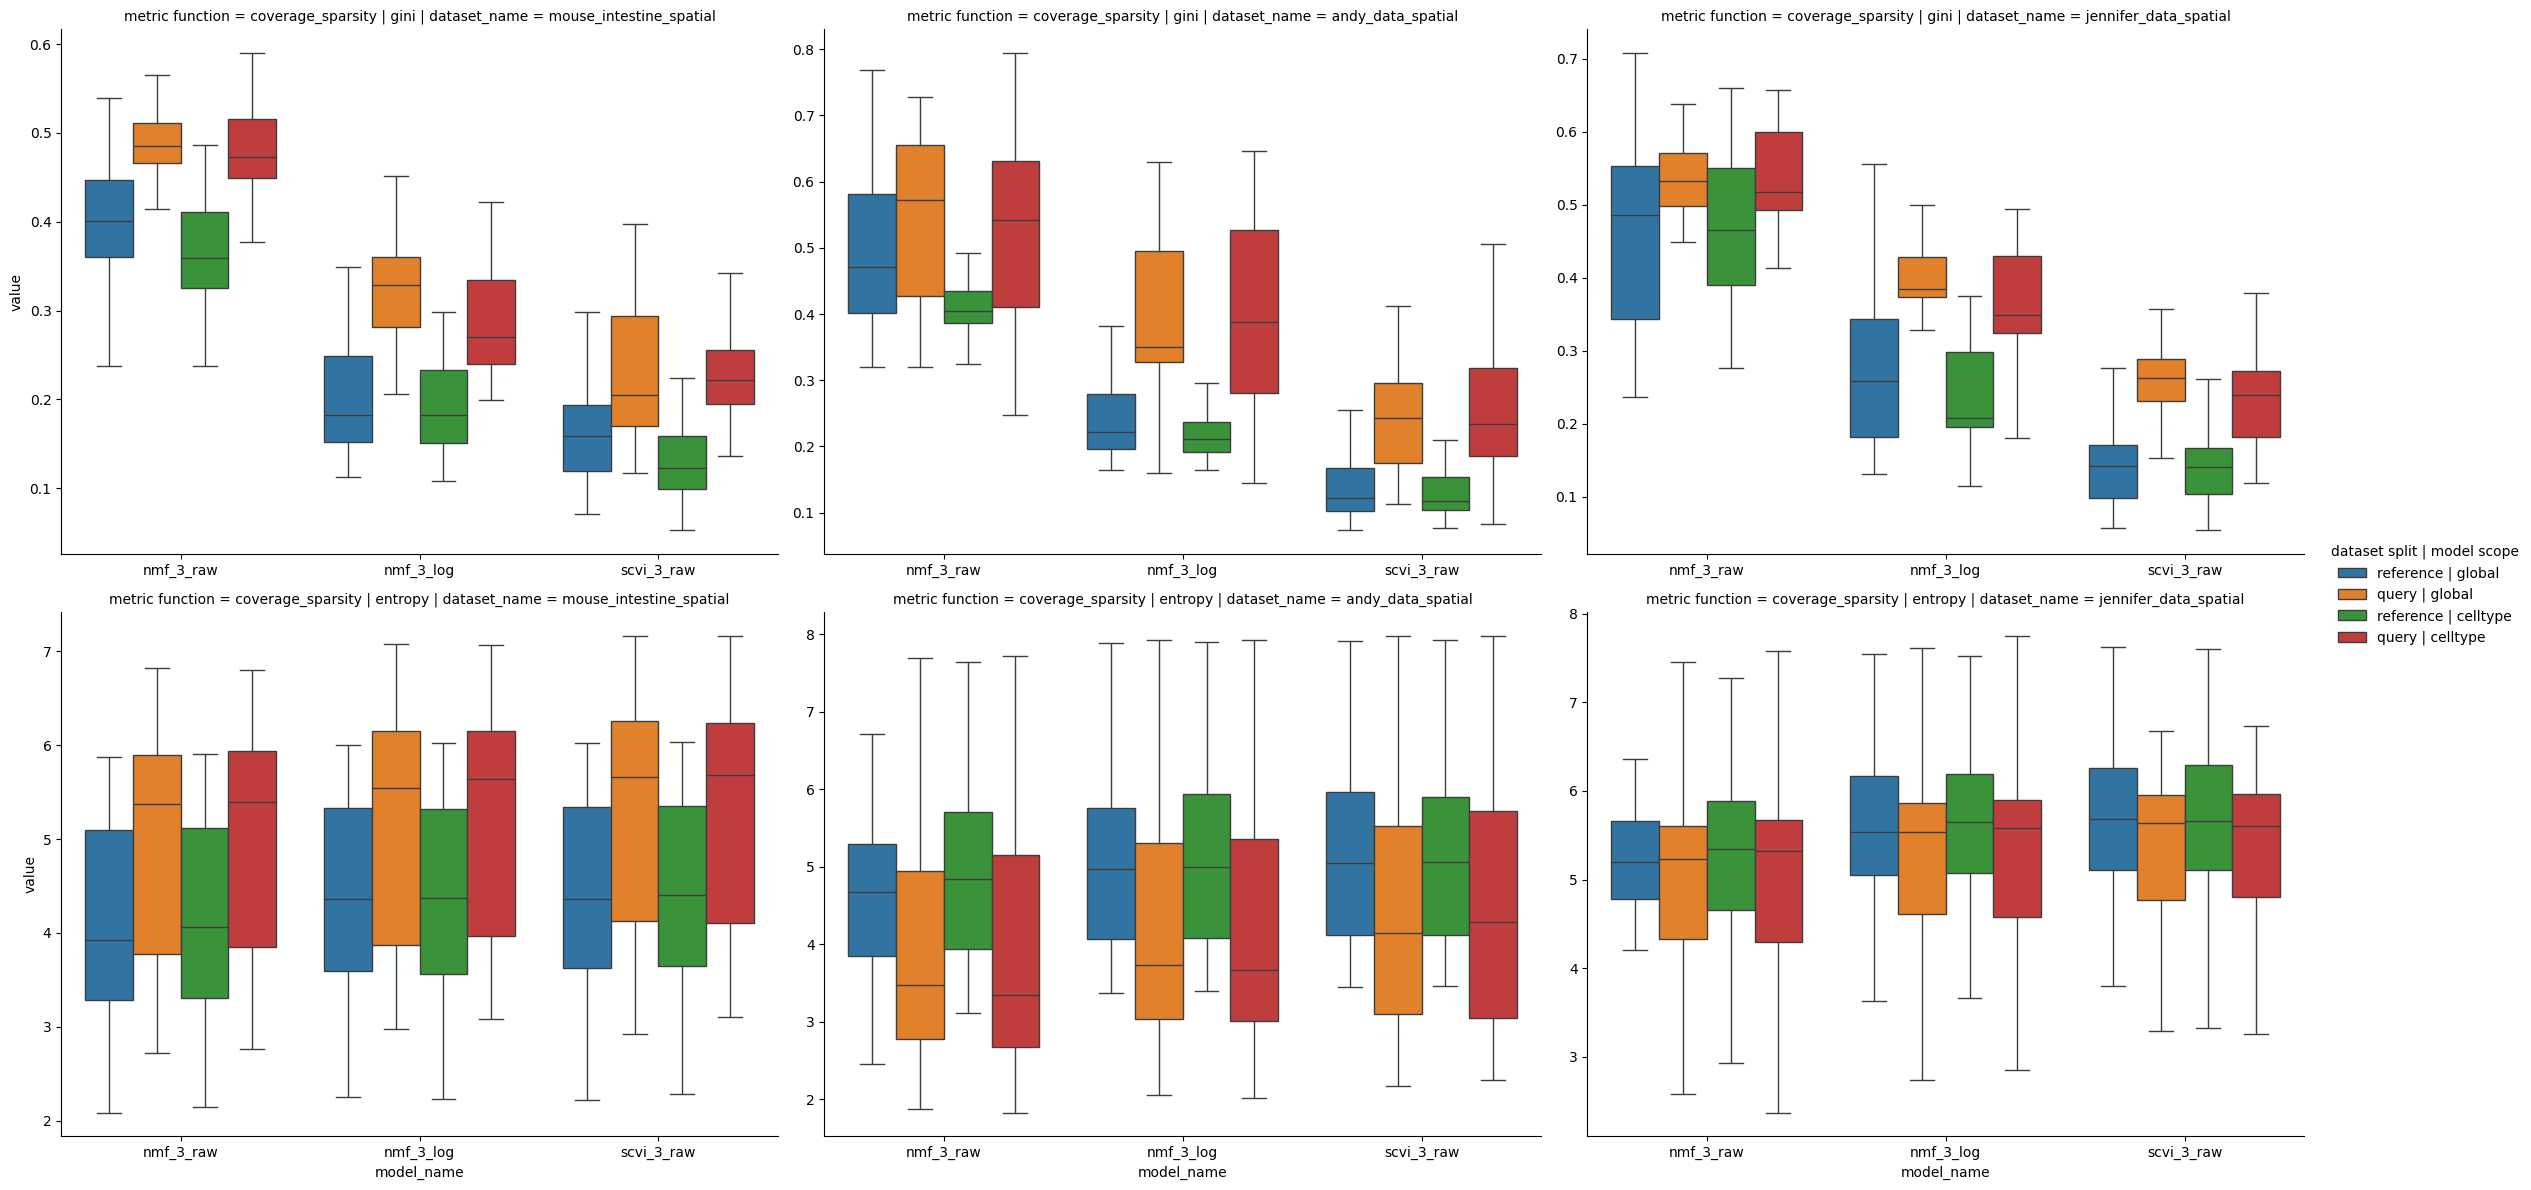

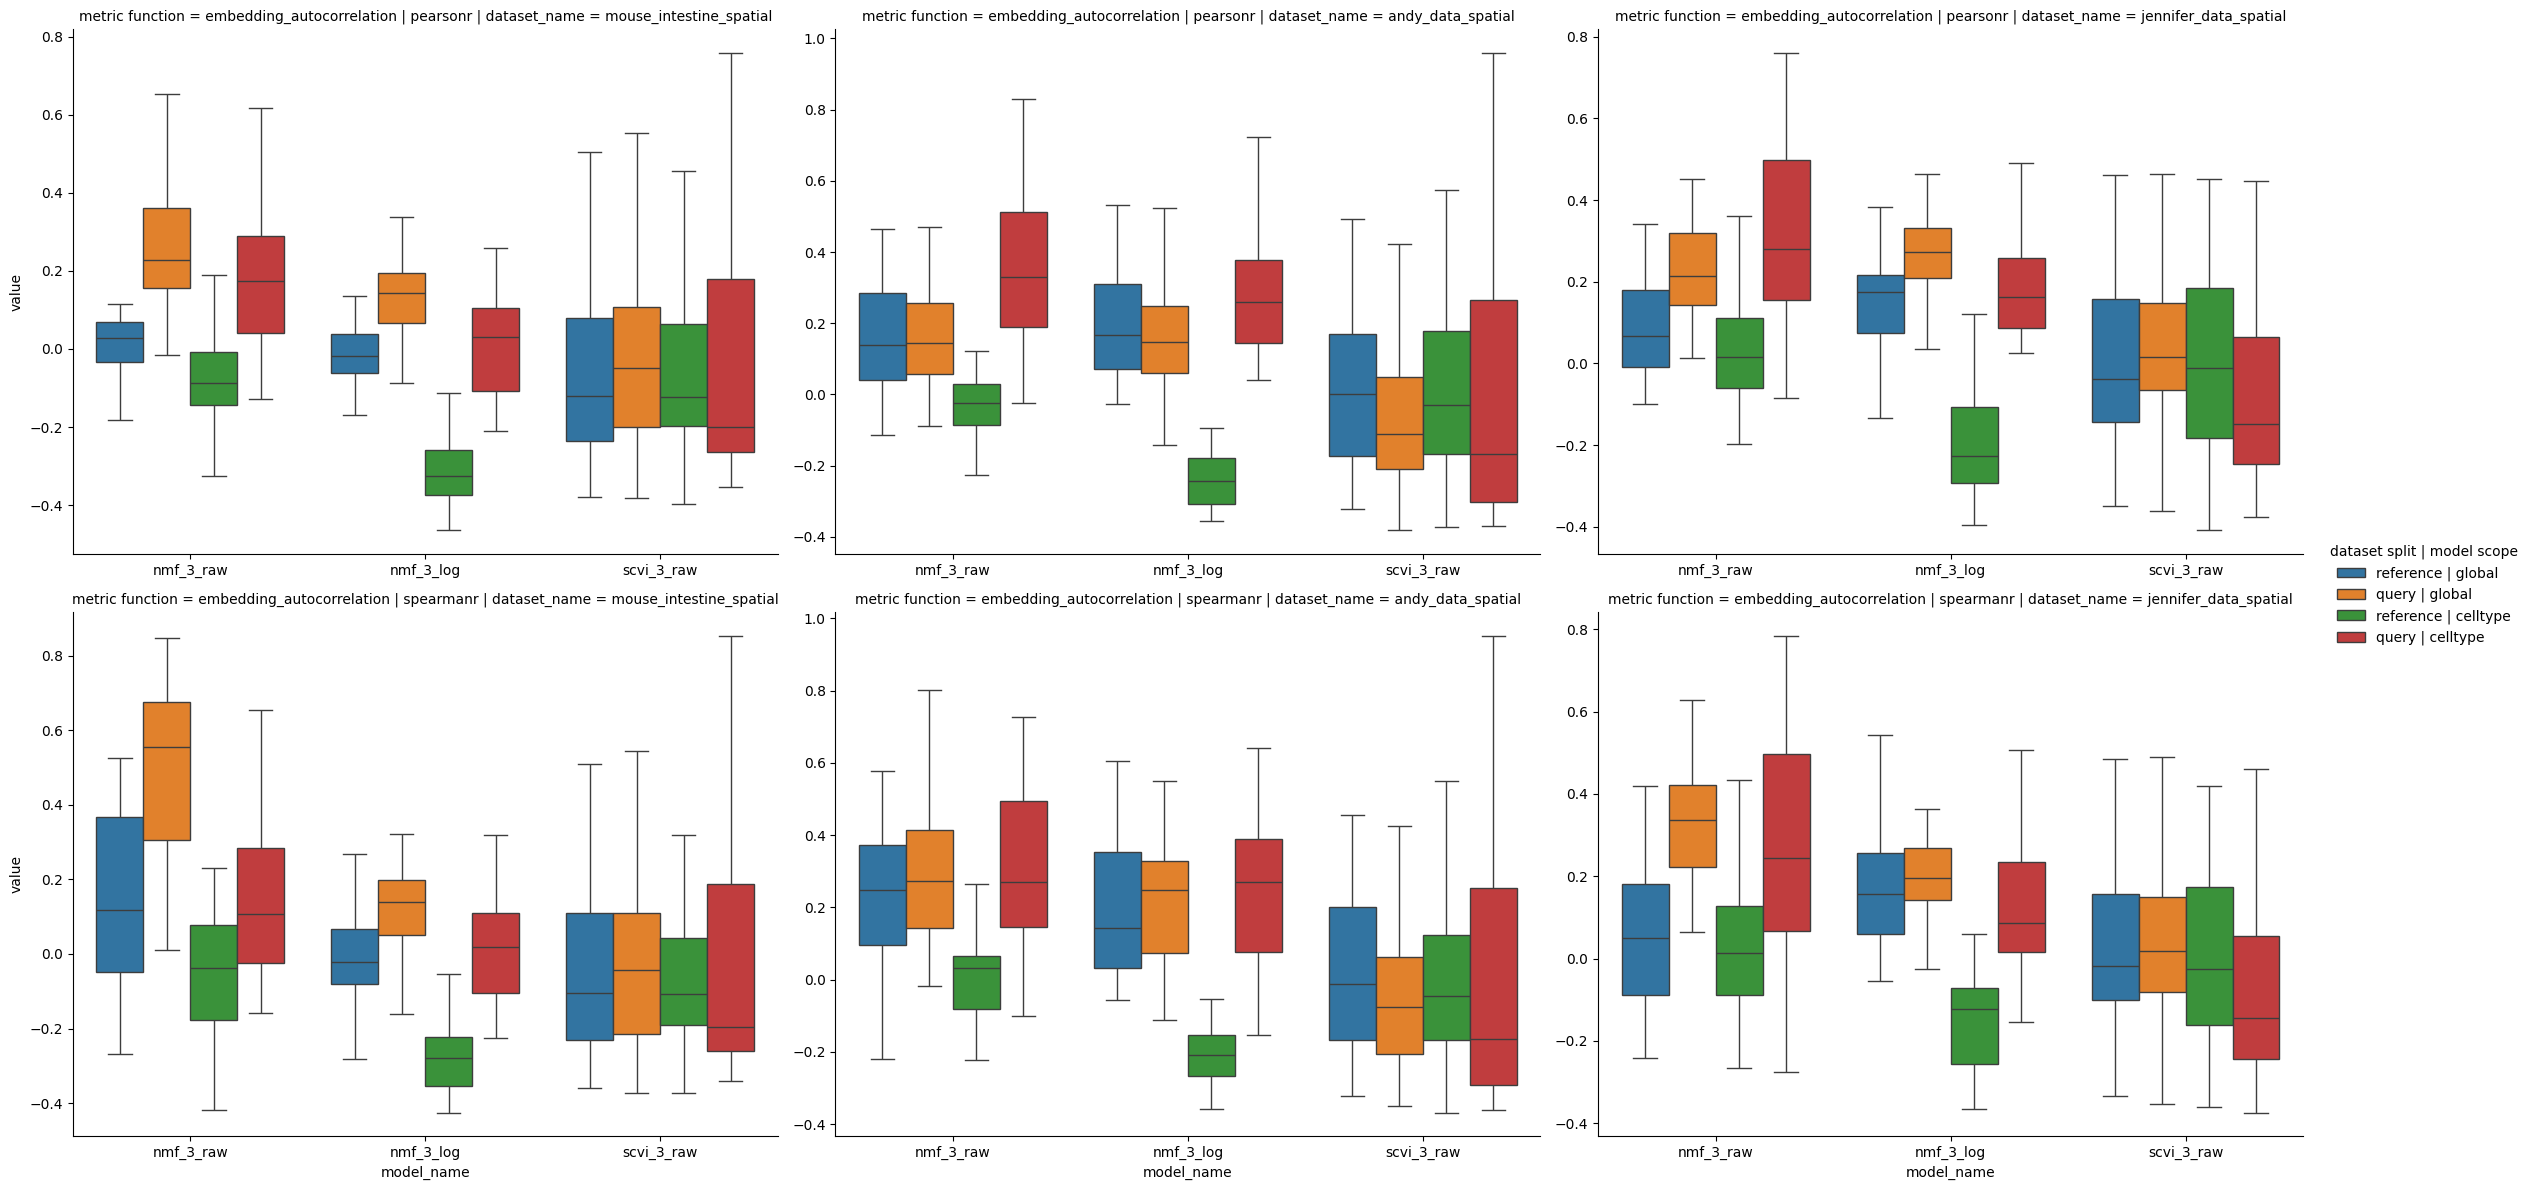

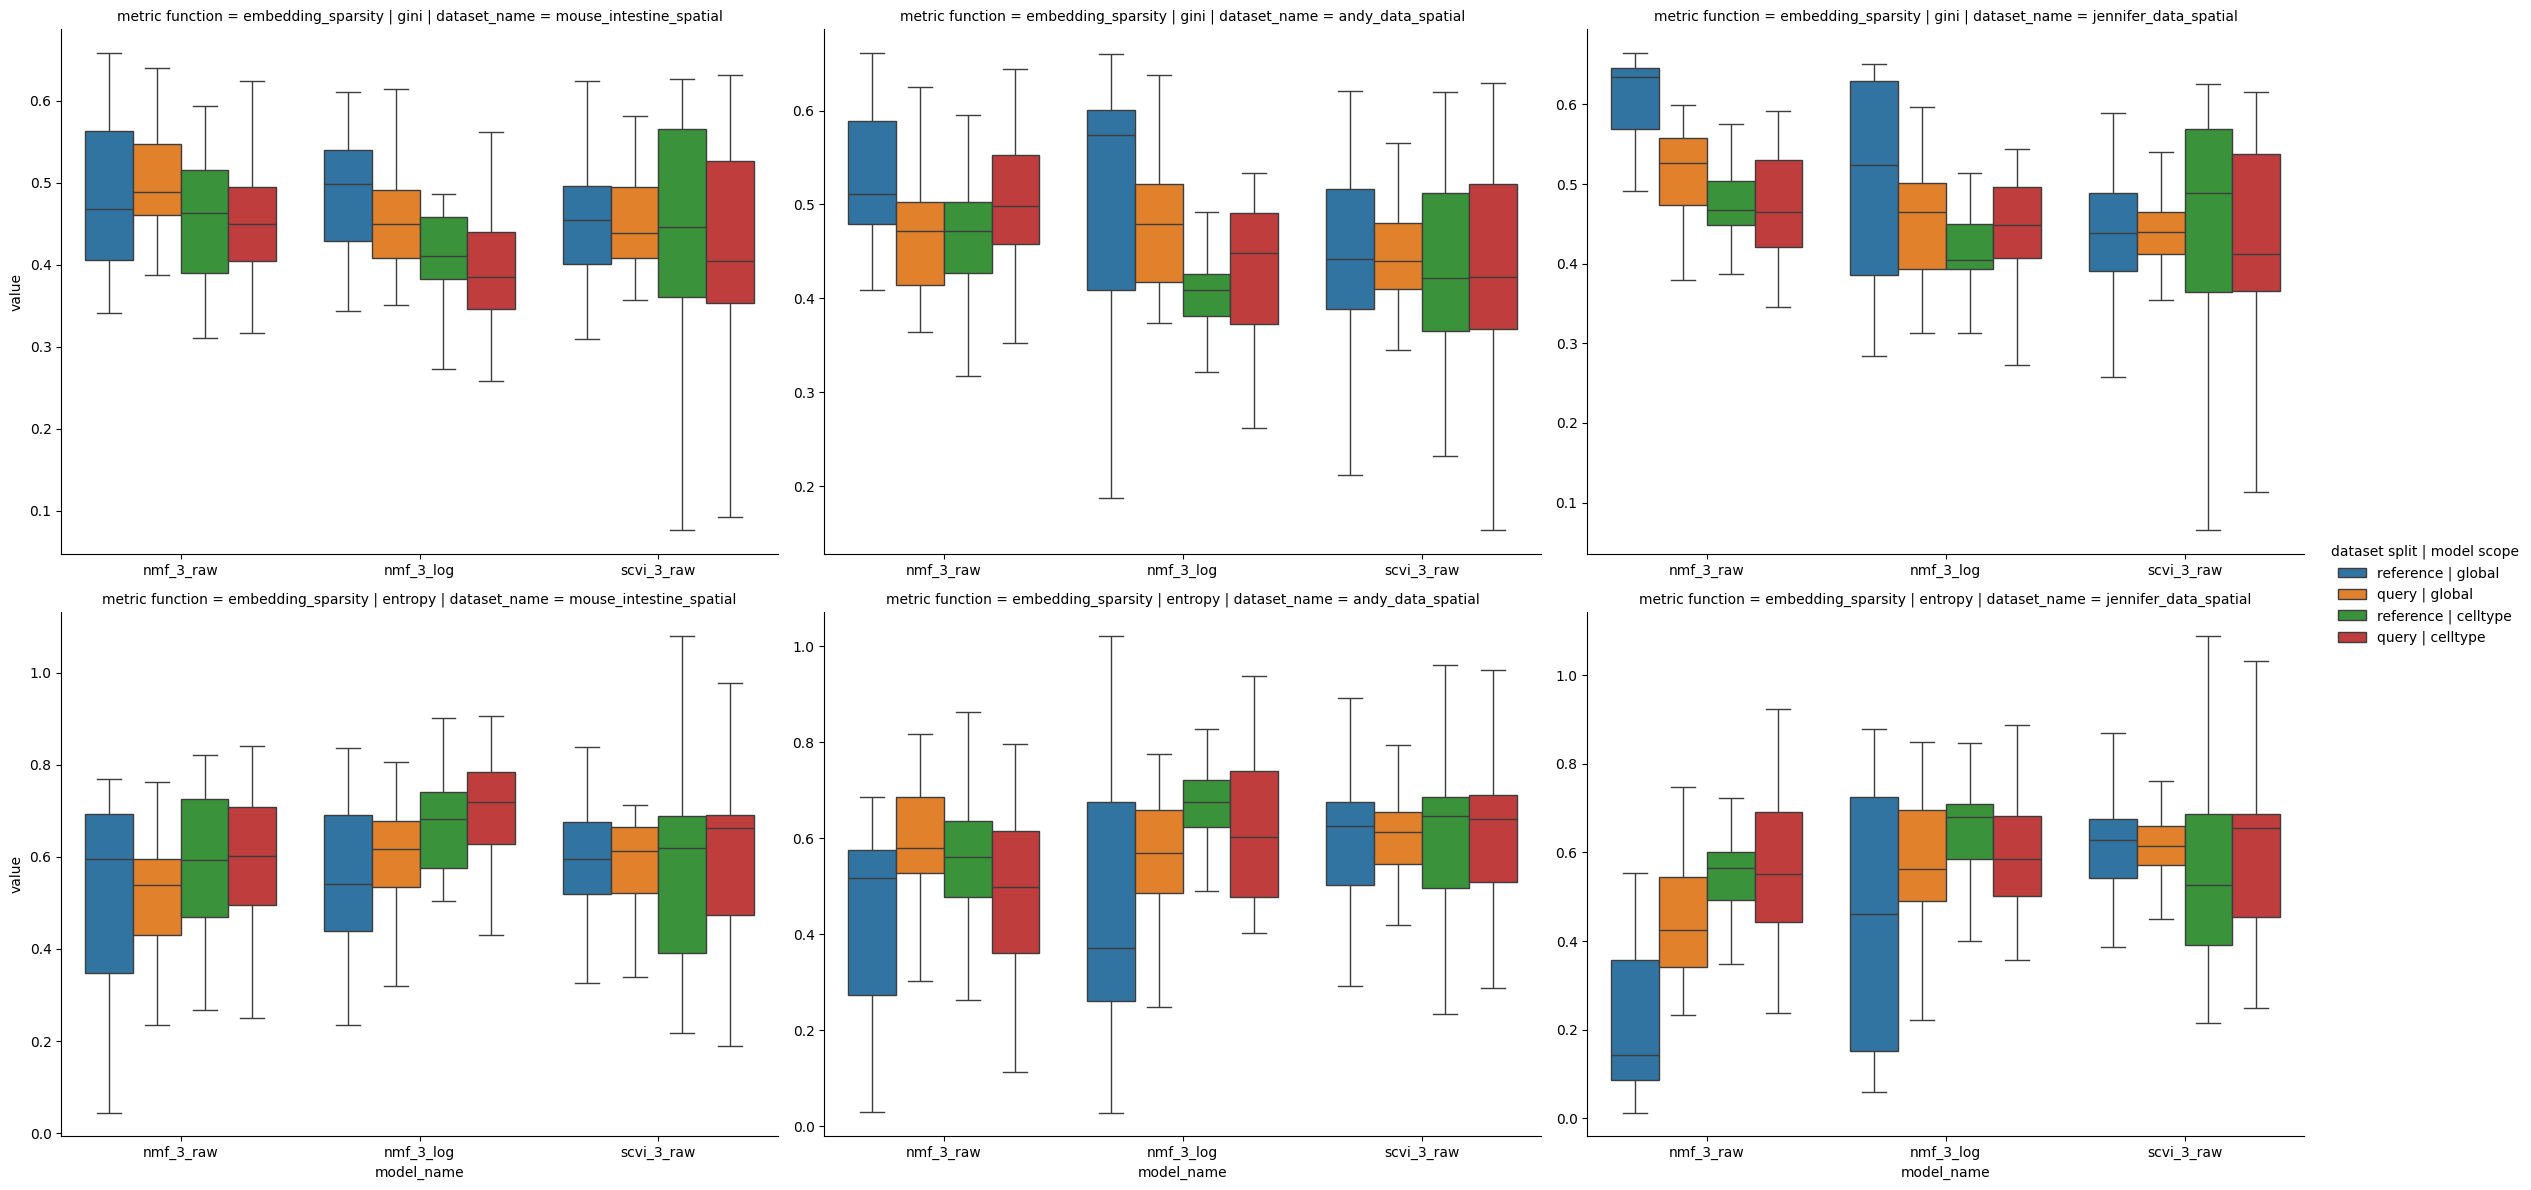

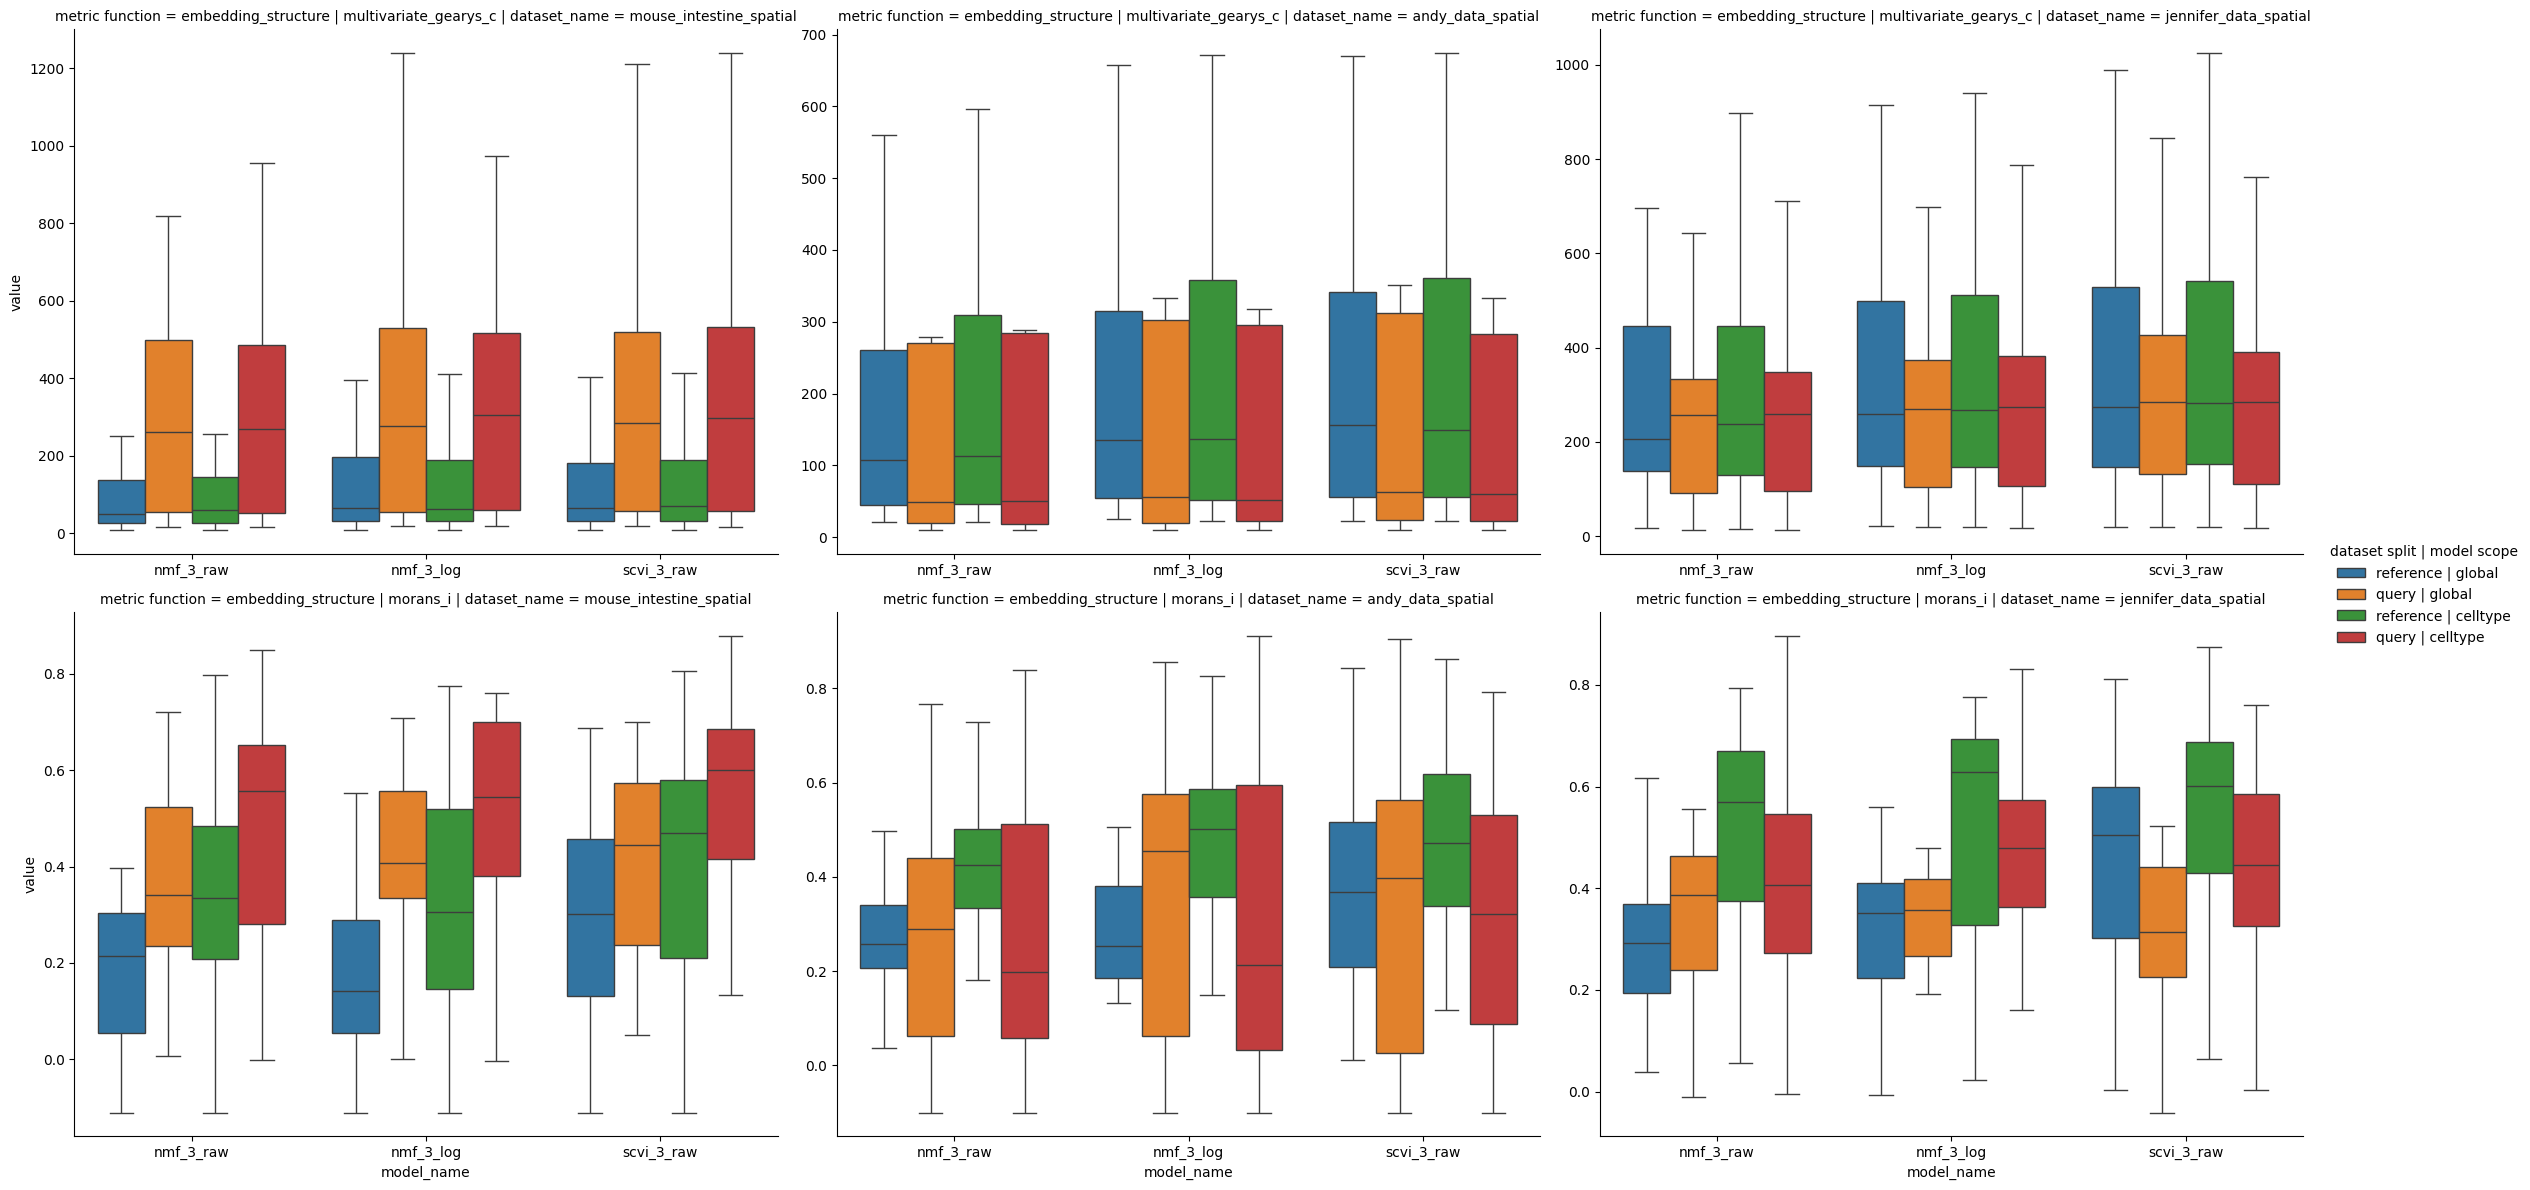

In [64]:
for metric_category, sub_df in results_df.groupby("metric_category"):
    sns.catplot(
        sub_df,
        x="model_name",
        y="value",
        hue="dataset split | model scope",
        kind="box",
        row="metric function",
        col="dataset_name",
        aspect=1.3,
        height=6,
        sharex=False,
        sharey=False,
        showfliers=False,
    )
    plt.show()

In [ ]:
example_database: GeneProgramsDB = frozenset(
    {
        ("Program_A", frozenset({"Gene A", "Gene B"})),
        ("Program_B", frozenset({"Gene B", "Gene C"})),
    }
)

import gseapy


In [ ]:
from ast import Call
from functools import cache, partial, reduce
from typing import NamedTuple

from anndata.typing import AnnData
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import non_negative_factorization
from sklearn.metrics.pairwise import cosine_similarity
import gseapy

GeneProgramsDB = frozenset[tuple[str, frozenset[str]]]


@cache
def get_gene_programs_db(organism: str, name: str) -> GeneProgramsDB:
    library: dict[str, list[str]] = gseapy.get_library(  # type: ignore
        organism=organism,
        name=name,
    )
    return frozenset((program, frozenset(genes)) for program, genes in library.items())  # type: ignore


def extract_gene_list(gene_programs_db: GeneProgramsDB) -> list[str]:
    return sorted(
        list(
            reduce(
                frozenset.union,
                [gene_set for _, gene_set in gene_programs_db],
            )
        )
    )


def get_gene_program_counts(
    gene_programs_db: GeneProgramsDB,
    genes: Sequence[str],
) -> NumericArray:
    binary_matrix = [
        [1 if gene in program_genes else 0 for gene in genes]
        for _, program_genes in gene_programs_db
    ]

    return np.array(binary_matrix)


def compute_prior_knowledge_score(
    a: NumericArray,
    sparstiy_func: Callable[[NumericArray], float],
) -> float:
    return float(np.mean([sparstiy_func(factor) for factor in a]))


def add_shuffle_noise_dense(
    counts: NumericArray,
    probability: float,
    rng: np.random.Generator | None,
) -> NumericArray:
    return (
        np.stack(
            [
                (rng or np.random.default_rng()).permutation(counts[:, i])
                if (rng or np.random.default_rng()).random() < probability
                else counts[:, i]
                for i in range(counts.shape[1])
            ],
            axis=1,
        )
        if probability != 0
        else counts
    )


def cca_correspondence_func(
    h: np.ndarray, gene_program_counts: np.ndarray
) -> np.ndarray:
    h = np.nan_to_num(h, nan=0.0, posinf=0.0, neginf=0.0)
    gene_program_counts = np.nan_to_num(
        gene_program_counts, nan=0.0, posinf=0.0, neginf=0.0
    )

    h = h[:, np.std(h, axis=0) > 1e-9]
    gpc = gene_program_counts[:, np.std(gene_program_counts, axis=0) > 1e-9]

    if h.shape[1] < 2 or gpc.shape[1] < 2:
        return np.array([0.0])

    cov_h = np.cov(h.T)
    cov_gpc = np.cov(gpc.T)

    n_comp = min(cov_h.shape[1], cov_gpc.shape[1], 5)

    try:
        cca = CCA(n_components=n_comp)
        h_c, gpc_c = cca.fit_transform(cov_h, cov_gpc)

        correlations = np.array(
            [np.corrcoef(h_c[:, i], gpc_c[:, i])[0, 1] for i in range(n_comp)]
        )
        return np.nan_to_num(correlations, nan=0.0)

    except Exception:
        return np.array([0.0])


def hoyer_sparsity_func(vector: NumericArray) -> float:
    """
    Calculates the Hoyer Sparsity of a vector.
    Returns a value between 0 (fully dense) and 1 (fully sparse).
    """
    n = len(vector)
    # Handle potential zero/constant vectors
    if np.all(vector == 0):
        return 1.0

    l1 = np.sum(np.abs(vector))
    l2 = np.sqrt(np.sum(vector**2))

    # Hoyer formula: (sqrt(n) - (L1/L2)) / (sqrt(n) - 1)
    numerator = np.sqrt(n) - (l1 / l2)
    denominator = np.sqrt(n) - 1

    return float(numerator / denominator)


def test_noise_score(
    data: tuple[Callable[[], AnnData], str, str],
    n_components: int,
    gene_programs_data: tuple[str, GeneProgramsDB],
    shuffle_probability: float | int,
    n_iterations: int,
    n_samples: int,
    rng: np.random.Generator | None,
    mat_func: tuple[str, Callable[[NumericArray, NumericArray], NumericArray]],
    sparsity_func: tuple[str, Callable[[NumericArray], float]],
) -> pd.DataFrame:
    """
    Correlates noise strength to scores across multiple bootstrap iterations.
    """
    results: list[dict[str, Any]] = []
    gene_programs_db_name, gene_programs_db = gene_programs_data
    gene_list = extract_gene_list(gene_programs_db)
    adata_loader, dataset_name, cluster_key = data
    adata = adata_loader()
    celltypes: list[str] = adata.obs[cluster_key].unique().tolist()
    gene_list = np.intersect1d(gene_list, adata.var_names).tolist()
    gene_program_counts = get_gene_program_counts(
        gene_programs_db=gene_programs_db,
        genes=gene_list,
    )
    adata = adata[:, gene_list]

    for celltype in celltypes:
        adata_ct = adata[adata.obs[cluster_key] == celltype]
        if adata_ct.n_obs == 0:
            print(f"Skipping {celltype}: No cells found in this category.")
            continue
        for indices in (rng or np.random.default_rng()).choice(
            adata_ct.n_obs, size=(n_iterations, n_samples), replace=True
        ):
            noisy_counts = add_shuffle_noise_dense(
                counts=adata_ct[indices, :].X.toarray(),
                probability=float(shuffle_probability),
                rng=rng,
            )
            _, h, _ = non_negative_factorization(
                X=np.log1p(noisy_counts),
                n_components=n_components,
            )

            a = mat_func[1](h, gene_program_counts)
            score = sparsity_func[1](a)

            results.append(
                {
                    "shuffle_probability": shuffle_probability,
                    "score": score,
                    "cluster": celltype,
                    "dataset_name": dataset_name,
                    "database_name": gene_programs_db_name,
                    "mat_func": mat_func[0],
                    "sparsity_func": sparsity_func[0],
                }
            )

    return pd.DataFrame(results)


class BenchmarkSample(NamedTuple):
    data: tuple[Callable[[], AnnData], str, str]
    gene_programs_data: tuple[str, GeneProgramsDB]
    shuffle_probability: float


def create_benchmark_run(
    n_components: int,
    n_iterations: int,
    n_samples: int,
    rng: np.random.Generator,
) -> Callable[[BenchmarkSample], pd.DataFrame]:
    def benchmark_run(benchmark_sample: BenchmarkSample) -> pd.DataFrame:
        print(benchmark_sample.gene_programs_data[0], benchmark_sample.data[1], "\n")
        dataframe = test_noise_score(
            data=benchmark_sample.data,
            n_components=n_components,
            gene_programs_data=benchmark_sample.gene_programs_data,
            shuffle_probability=benchmark_sample.shuffle_probability,
            n_iterations=n_iterations,
            n_samples=n_samples,
            rng=rng,
        )
        return dataframe

    return benchmark_run


N_COMPONENTS: int = 2
N_ITERATIONS: int = 1
N_SAMPLES: int = 500
SEED: int = 0
DATABASE_NAMES: Sequence[str] = [
    "GO_Biological_Process_2026",
    "KEGG_2021_Human",
    "WikiPathways_2024_Human",
    "Reactome_Pathways_2024",
    "MSigDB_Hallmark_2020",
    "GeneSigDB",
    "GO_Molecular_Function_2026",
    "Enrichr_Libraries_Most_Popular_Genes",
]
DATASETS: Sequence[tuple[Callable[[], AnnData], str, str]] = [
    (
        sc.datasets.paul15,
        "paul15",
        "paul15_clusters",
    ),
    # (
    #    partial(
    #        sc.read_h5ad,
    #        filename="/home/gruengroup/alex/datasets/jennifer/bones/reference/adata_raw.h5ad",
    #    ),
    #    "Jennifer_Bonemarrow",
    #    "cell_type",
    # ),
]
SHUFFLE_PROBABILITIES: Sequence[float] = [0.0, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
OUTPUT_CSV_PATH: str = "./biological_interpretability_benchmark.csv"


def main() -> None:
    benchmark_run = create_benchmark_run(
        n_components=N_COMPONENTS,
        n_iterations=N_ITERATIONS,
        n_samples=N_SAMPLES,
        rng=np.random.default_rng(SEED),
    )
    benchmark_samples: list[BenchmarkSample] = [
        BenchmarkSample(
            data=data,
            gene_programs_data=(
                database_name,
                get_gene_programs_db(name=database_name, organism="Human"),
            ),
            shuffle_probability=shuffle_probability,
        )
        for data, database_name, shuffle_probability in product(
            DATASETS, DATABASE_NAMES, SHUFFLE_PROBABILITIES
        )
    ]
    dataframe = pd.concat(
        map(benchmark_run, tqdm(benchmark_samples, desc="Running Benchmarks"))
    )
    dataframe["z_score"] = dataframe.groupby("cluster")["score"].transform(
        lambda x: (x - x.mean()) / x.std()
    )
    dataframe.to_csv(OUTPUT_CSV_PATH)


if __name__ == "__main__":
    main()

INFO: Downloading and generating Enrichr library gene sets...
INFO: 0002 gene_sets have been filtered out when max_size=2000 and min_size=0
INFO: Downloading and generating Enrichr library gene sets...
INFO: Downloading and generating Enrichr library gene sets...
INFO: Downloading and generating Enrichr library gene sets...
INFO: 0005 gene_sets have been filtered out when max_size=2000 and min_size=0
INFO: Downloading and generating Enrichr library gene sets...
INFO: Downloading and generating Enrichr library gene sets...
INFO: 0013 gene_sets have been filtered out when max_size=2000 and min_size=0
INFO: Downloading and generating Enrichr library gene sets...
INFO: Downloading and generating Enrichr library gene sets...




GO_Biological_Process_2026 paul15 



GO_Biological_Process_2026 paul15 



GO_Biological_Process_2026 paul15 



GO_Biological_Process_2026 paul15 



...

Enrichr_Libraries_Most_Popular_Genes paul15 

Enrichr_Libraries_Most_Popular_Genes paul15 



Enrichr_Libraries_Most_Popular_Genes paul15 

Enrichr_Libraries_Most_Popular_Genes paul15 



Enrichr_Libraries_Most_Popular_Genes paul15 

Enrichr_Libraries_Most_Popular_Genes paul15 



Enrichr_Libraries_Most_Popular_Genes paul15 

Enrichr_Libraries_Most_Popular_Genes paul15 





Running Benchmarks: 100%|████████████████████████████████████████████| 64/64 [00:39<00:00,  1.63it/s]


In [569]:
from collections.abc import Generator, Hashable


def obs_iterator(
    adata: AnnData,
    keys: list[str],
) -> Generator[tuple[tuple[Hashable, ...], pd.Index], None, None]:
    for value, obs_df in adata.obs.groupby(keys):  # type: ignore
        yield value, obs_df.index

In [530]:
def create_run(
    data: tuple[Callable[[], AnnData], str, str],
    n_components: int,
    gene_programs_data: tuple[str, GeneProgramsDB],
    shuffle_probability: float | int,
    n_iterations: int,
    n_samples: int,
    rng: np.random.Generator | None,
) -> pd.DataFrame:
    results: list[dict[str, Any]] = []
    gene_programs_db_name, gene_programs_db = gene_programs_data
    gene_list = extract_gene_list(gene_programs_db)
    adata_loader, dataset_name, cluster_key = data
    adata = adata_loader()
    celltypes: list[str] = adata.obs[cluster_key].unique().tolist()
    gene_list = np.intersect1d(gene_list, adata.var_names).tolist()
    gene_program_counts = get_gene_program_counts(
        gene_programs_db=gene_programs_db,
        genes=gene_list,
    )
    adata = adata[:, gene_list]

    for celltype in celltypes:
        adata_ct = adata[adata.obs[cluster_key] == celltype]
        if adata_ct.n_obs == 0:
            print(f"Skipping {celltype}: No cells found in this category.")
            continue
        for indices in (rng or np.random.default_rng()).choice(
            adata_ct.n_obs, size=(n_iterations, n_samples), replace=True
        ):
            noisy_counts = add_shuffle_noise_dense(
                counts=adata_ct[indices, :].X.toarray(),
                probability=float(shuffle_probability),
                rng=rng,
            )
            _, h, _ = non_negative_factorization(
                X=np.log1p(noisy_counts),
                n_components=n_components,
            )

            score = compute_prior_knowledge_score(
                h=h,
                gene_program_counts=gene_program_counts,
                mat_func=cosine_similarity,
                sparstiy_func=gini,
            )

            results.append(
                {
                    "shuffle_probability": shuffle_probability,
                    "score": score,
                    "cluster": celltype,
                    "dataset_name": dataset_name,
                    "database_name": gene_programs_db_name,
                }
            )

    return pd.DataFrame(results)

In [ ]:
create_run2: Callable[
    [tuple[Callable[[], AnnData], str, str], tuple[str, GeneProgramsDB], str | int],
    pd.DataFrame,
] = partial(  # type: ignore
    create_run,
    n_components=N_COMPONENTS,
    n_iterations=N_ITERATIONS,
    n_samples=N_SAMPLES,
    rng=np.random.default_rng(SEED),
)

In [ ]:
DATASETS, DATABASE_NAMES, SHUFFLE_PROBABILITIES

In [535]:
create_run2(data=data)

NameError: name 'data' is not defined

In [ ]:
[(a, b) for a in list_a for b in list_b]

[(1, 1), (1, 2), (2, 1), (2, 2)]

In [321]:
arr = cosine_similarity(
    np.array([[0, 1], [0, 1]]),
    np.array([[1, 0], [1, 0]]),
)
print(arr, gini(arr))

[[0. 0.]
 [0. 0.]] nan


In [ ]:
_, h, _ = non_negative_factorization(
    adata[adata.obs["cell_type"] == "B.prog"][:1000].X, n_components=2
)

In [362]:
def placholder(
    data: tuple[Callable[[], AnnData], str, str],
    gene_programs_data: tuple[str, GeneProgramsDB],
) -> pd.DataFrame:
    """
    Correlates noise strength to scores across multiple bootstrap iterations.
    """
    gene_list = extract_gene_list(gene_programs_db)
    adata_loader, dataset_name, cluster_key = data
    adata = adata_loader()
    gene_list = np.intersect1d(gene_list, adata.var_names).tolist()
    gene_program_counts = get_gene_program_counts(
        gene_programs_db=gene_programs_db,
        genes=gene_list,
    )
    adata = adata[:, gene_list]
    return adata, gene_program_counts

In [ ]:
myadata, gene_programs_counts = placholder(
    data=((lambda: adata), "a", "a"),
    gene_programs_data=(
        "a",
        get_gene_programs_db(organism="Human", name=DATABASE_NAMES[0]),
    ),
)

In [370]:
_, h, _ = non_negative_factorization(myadata[:1000].X, n_components=2)

In [381]:
print(h.shape, gene_programs_counts.shape)
CCA(n_components=1).fit_transform(h.T, gene_programs_counts.T)

(2, 14754) (5952, 14754)


(array([[-0.13996541],
        [-0.16285844],
        [-0.16368731],
        ...,
        [-0.11609429],
        [-0.03487946],
        [ 0.04380115]], shape=(14754, 1)),
 array([[-0.06227718],
        [ 0.03822576],
        [ 0.00613317],
        ...,
        [-0.03726644],
        [-0.01127636],
        [-0.05831473]], shape=(14754, 1)))

In [378]:
CCA(n_components=1).fit_transform(h, gene_programs_counts)

ValueError: Found input variables with inconsistent numbers of samples: [2, 5952]

In [355]:
from sklearn.cross_decomposition import CCA

x = np.array([[1, 0], [1, 0]])
y = np.array([[1, 0], [0, 1]])


CCA(n_components=1).fit_transform(x, y)

ValueError: A has a NaN entry

In [353]:
x, y

(array([[1, 0],
        [1, 0]]),
 array([[1, 0],
        [0, 1]]))

In [354]:
from sklearn.cross_decomposition import CCA


CCA(n_components=1).fit_transform(x, y)

ValueError: A has a NaN entry

In [ ]:
adata = sc.read_h5ad(
    filename="/home/gruengroup/alex/datasets/jennifer/bones/reference/adata_raw.h5ad"
)
non_negative_factorization(
    adata[adata.obs["cell_type"] == "B.prog"][:1000].X, n_components=2
)

In [ ]:
non_negative_factorization(
    adata[adata.obs["cell_type"] == "B.prog"][:1000].X, n_components=2
)

(array([[2.37148673, 0.65594641],
        [3.88200769, 0.        ],
        [0.53763084, 0.78743823],
        ...,
        [3.66964261, 1.37420597],
        [0.91342674, 3.14711274],
        [1.73124573, 2.32082124]], shape=(1000, 2)),
 array([[0.00524565, 0.01733785, 0.00090937, ..., 0.0030761 , 0.        ,
         0.59671368],
        [0.01657579, 0.00165137, 0.        , ..., 0.        , 0.        ,
         0.09969551]], shape=(2, 60642)),
 84)

In [393]:
dataframe = pd.read_csv(OUTPUT_CSV_PATH, index_col=0)
dataframe["z_score"] = dataframe.groupby(["cluster", "dataset_name", "database_name"])[
    "score"
].transform(lambda x: (x - x.mean()) / x.std())
dataframe = dataframe.melt(
    id_vars=["shuffle_probability", "cluster", "dataset_name", "database_name"]
)
dataframe

,shuffle_probability,cluster,dataset_name,database_name,variable,value
0,0.0,7MEP,paul15,GO_Biological_Process_2026,score,0.994680
1,0.0,15Mo,paul15,GO_Biological_Process_2026,score,0.989734
2,0.0,3Ery,paul15,GO_Biological_Process_2026,score,0.992718
3,0.0,4Ery,paul15,GO_Biological_Process_2026,score,0.994011
4,0.0,2Ery,paul15,GO_Biological_Process_2026,score,0.994223
...,...,...,...,...,...,...
2427,1.0,6Ery,paul15,Enrichr_Libraries_Most_Popular_Genes,z_score,-1.406342
2428,1.0,19Lymph,paul15,Enrichr_Libraries_Most_Popular_Genes,z_score,-0.535532
2429,1.0,12Baso,paul15,Enrichr_Libraries_Most_Popular_Genes,z_score,-1.922491
2430,1.0,18Eos,paul15,Enrichr_Libraries_Most_Popular_Genes,z_score,-0.585540


In [440]:
def factor_gene_correlations(
    x: NumericArray,
    w: NumericArray,
    corr_func: Callable[[NumericArray, NumericArray], float],
) -> NumericArray:
    return np.array(
        [
            [
                corr_func(factor_distribution.flatten(), gene_distribution.flatten())
                for factor_distribution in w.T
            ]
            for gene_distribution in x.T
        ]
    ).T


In [436]:
counts = np.log1p(adata[:1000, :1000].X).toarray()
w, h, _ = non_negative_factorization(np.log1p(counts), n_components=2)

In [443]:
h_pearson = factor_gene_correlations(counts, w, n2l.mt.pearson_metric)

In [ ]:
gene_list: list[str] = adata.var_names[np.argpartition(h[0], -100)[-100:]].tolist()

In [473]:
df_enrichment = gseapy.enrichr(
    gene_list=gene_list,
    gene_sets=["MSigDB_Hallmark_2020", "KEGG_2021_Human"],
)

In [474]:
df_enrichment.results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,MSigDB_Hallmark_2020,G2-M Checkpoint,9/200,7.246131e-07,0.000012,0,0,10.205454,144.280915,H2AZ2;XPO1;NUP50;STMN1;ATRX;MCM3;MCM5;CTCF;HMGN2
1,MSigDB_Hallmark_2020,E2F Targets,9/200,7.246131e-07,0.000012,0,0,10.205454,144.280915,DNMT1;XPO1;STMN1;MCM3;MCM5;BRCA1;CTCF;CNOT9;DCK
2,MSigDB_Hallmark_2020,Myc Targets V1,5/200,3.323821e-03,0.035454,0,0,5.318489,30.350700,PSMD7;XPO1;MRPS18B;MCM5;HNRNPA1
3,MSigDB_Hallmark_2020,DNA Repair,4/150,6.831782e-03,0.054654,0,0,5.637557,28.109817,DDB1;FEN1;EDF1;APRT
4,MSigDB_Hallmark_2020,Apical Surface,2/44,2.042948e-02,0.130749,0,0,9.649174,37.542776,APP;BRCA1
...,...,...,...,...,...,...,...,...,...,...
173,KEGG_2021_Human,Ras signaling pathway,1/232,6.895374e-01,0.708961,0,0,0.860073,0.319718,PRKACB
174,KEGG_2021_Human,Calcium signaling pathway,1/240,7.018836e-01,0.716608,0,0,0.830945,0.294145,PRKACB
175,KEGG_2021_Human,Salmonella infection,1/249,7.151927e-01,0.725126,0,0,0.800424,0.268305,SKP1
176,KEGG_2021_Human,Pathways in cancer,2/531,7.479688e-01,0.753127,0,0,0.747309,0.217014,PRKACB;SKP1


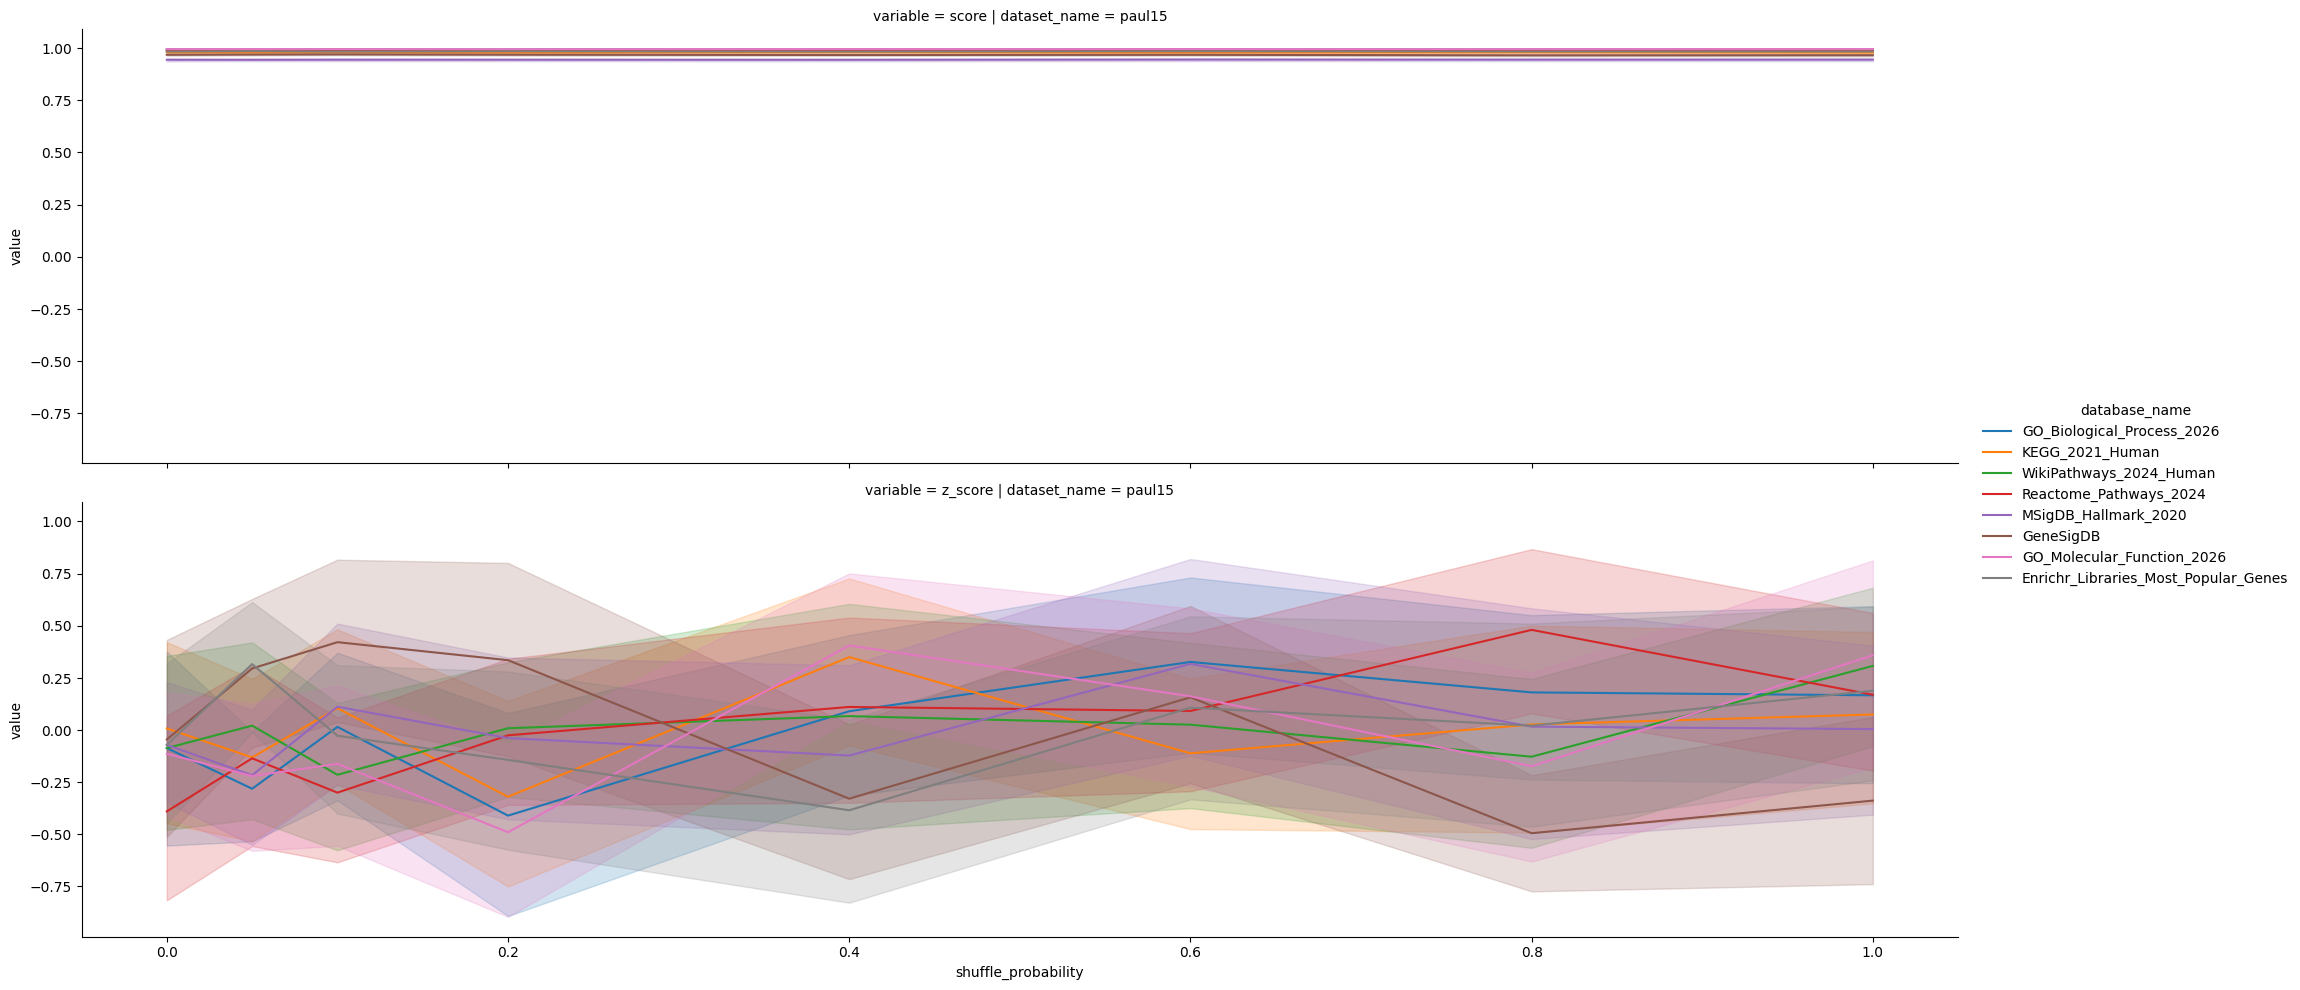

In [407]:
sns.relplot(
    data=dataframe,
    x="shuffle_probability",
    y="value",
    hue="database_name",
    row="variable",
    col="dataset_name",
    aspect=4,
    kind="line",
)

In [229]:
dataframe

,shuffle_probability,score,cluster,dataset_name,database_name,z_score
0,0.0,0.994753,7MEP,paul15,GO_Biological_Process_2026,-0.738592
1,0.0,0.990379,15Mo,paul15,GO_Biological_Process_2026,-2.345332
2,0.0,0.992514,3Ery,paul15,GO_Biological_Process_2026,-0.270212
3,0.0,0.994170,4Ery,paul15,GO_Biological_Process_2026,0.897359
4,0.0,0.994217,2Ery,paul15,GO_Biological_Process_2026,1.723313
...,...,...,...,...,...,...
14,1.0,0.980851,6Ery,paul15,KEGG_2021_Human,-0.003276
15,1.0,0.993451,19Lymph,paul15,KEGG_2021_Human,1.212481
16,1.0,0.992697,12Baso,paul15,KEGG_2021_Human,-1.699909
17,1.0,0.991719,18Eos,paul15,KEGG_2021_Human,-0.595344


In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.graph_objs._figure import Figure


def radar_plot(
    df: pd.DataFrame,
    x: str,
    y: str,
    range: tuple[int | float, int | float] | None,
    title: str | None,
) -> Figure:
    # 1. Aggregate data for Median and Quartiles (Q1 and Q3)
    stats: pd.DataFrame = (
        df.groupby(x)[y]
        .agg(
            [
                ("median", "median"),
                ("q1", lambda x: x.quantile(0.25)),
                ("q3", lambda x: x.quantile(0.75)),
            ]
        )
        .reset_index()
    )

    # 2. Extract metrics and close the loop for Plotly
    metrics = stats[x].tolist()
    metrics_closed = metrics + [metrics[0]]

    median_closed = stats["median"].tolist() + [stats["median"].iloc[0]]
    q1_closed = stats["q1"].tolist() + [stats["q1"].iloc[0]]
    q3_closed = stats["q3"].tolist() + [stats["q3"].iloc[0]]

    fig = go.Figure()

    # 3. Add the Lower Bound (Q1) - The reference for the fill
    fig = fig.add_trace(
        go.Scatterpolar(
            r=q1_closed,
            theta=metrics_closed,
            mode="lines",
            line=dict(width=0),
            showlegend=False,
            hoverinfo="skip",
        )
    )

    # 4. Add the Upper Bound (Q3) and fill to 'tonext'
    fig = fig.add_trace(
        go.Scatterpolar(
            r=q3_closed,
            theta=metrics_closed,
            mode="lines",
            line=dict(width=0),
            fill="tonext",
            fillcolor="rgba(0, 100, 255, 0.2)",  # Semi-transparent blue
            name="IQR (Q1-Q3)",
        )
    )

    # 5. Add the Median Line
    fig = fig.add_trace(
        go.Scatterpolar(
            r=median_closed,
            theta=metrics_closed,
            mode="lines+markers",
            line=dict(color="blue", width=3),
            name="Median",
        )
    )

    fig = fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True, range=range, tickfont_size=10, gridcolor="lightgrey"
            )
        ),
        title=title,
    )

    return fig


In [74]:
results_df

,dataset_name,celltype,sample_id,model_name,metric_category,function_name,model_scope,dataset_split,value,value_transformed,dataset split | model scope,metric function,normalized_value_transformed
0,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,global,reference,0.075507,-0.075507,reference | global,embedding_autocorrelation | pearsonr,0.923057
1,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,global,query,0.371692,-0.371692,query | global,embedding_autocorrelation | pearsonr,0.619207
2,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,celltype,reference,-0.089689,-0.089689,reference | celltype,embedding_autocorrelation | pearsonr,0.908509
3,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,celltype,query,0.139297,-0.139297,query | celltype,embedding_autocorrelation | pearsonr,0.857617
4,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.107008,-0.107008,reference | global,embedding_autocorrelation | spearmanr,0.890563
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18715,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,gini,celltype,query,0.248340,-0.248340,query | celltype,coverage_sparsity | gini,0.703540
18716,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,entropy,global,reference,5.491333,5.491333,reference | global,coverage_sparsity | entropy,0.572411
18717,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,entropy,global,query,4.822649,4.822649,query | global,coverage_sparsity | entropy,0.449761
18718,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,entropy,celltype,reference,5.665626,5.665626,reference | celltype,coverage_sparsity | entropy,0.604379


In [ ]:
results_df = results_df.assign(
    normalized_value_transformed=lambda d: d.groupby(
        ["metric function", "dataset_name", "dataset_split", "model_scope"]
    )["value_transformed"].transform(lambda x: (x - x.min()) / (x.max() - x.min()))
)

In [109]:
column

'normalized_value_transformed'

In [ ]:
for (
    model_name,
    dataset_name,
    model_scope,
    dataset_split,
), sub_df in results_df.groupby(
    ["model_name", "dataset_name", "model_scope", "dataset_split"]
):
    fig = radar_plot(
        sub_df,
        x="metric function",
        y="normalized_value_transformed",
        range=None,
        title=model_name + " " + dataset_name + " " + model_scope + " " + dataset_split,
    )
    fig.show()

In [137]:
results_df

,dataset_name,celltype,sample_id,model_name,metric_category,function_name,model_scope,dataset_split,value,value_transformed,dataset split | model scope,metric function,normalized_value_transformed
0,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,global,reference,0.075507,-0.075507,reference | global,embedding_autocorrelation | pearsonr,0.906387
1,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,global,query,0.371692,-0.371692,query | global,embedding_autocorrelation | pearsonr,0.557120
2,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,celltype,reference,-0.089689,-0.089689,reference | celltype,embedding_autocorrelation | pearsonr,0.910124
3,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,celltype,query,0.139297,-0.139297,query | celltype,embedding_autocorrelation | pearsonr,0.858278
4,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.107008,-0.107008,reference | global,embedding_autocorrelation | spearmanr,0.868713
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18715,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,gini,celltype,query,0.248340,-0.248340,query | celltype,coverage_sparsity | gini,0.759180
18716,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,entropy,global,reference,5.491333,5.491333,reference | global,coverage_sparsity | entropy,0.553116
18717,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,entropy,global,query,4.822649,4.822649,query | global,coverage_sparsity | entropy,0.429467
18718,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,entropy,celltype,reference,5.665626,5.665626,reference | celltype,coverage_sparsity | entropy,0.618841


In [136]:
df = (
    results_df.groupby(
        [
            "dataset_name",
            "dataset_split",
            "model_scope",
            "function_name",
            "model_name",
            "sample_id",
        ]
    )["value"]
    .mean()
    .reset_index()
)
df

,dataset_name,dataset_split,model_scope,function_name,model_name,sample_id,value
0,andy_data_spatial,query,celltype,entropy,nmf_3_log,0,2.496006
1,andy_data_spatial,query,celltype,entropy,nmf_3_log,1,2.490472
2,andy_data_spatial,query,celltype,entropy,nmf_3_log,2,2.532185
3,andy_data_spatial,query,celltype,entropy,nmf_3_raw,0,2.304340
4,andy_data_spatial,query,celltype,entropy,nmf_3_raw,1,2.291264
...,...,...,...,...,...,...,...
643,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_raw,1,0.145751
644,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_raw,2,0.135316
645,mouse_intestine_spatial,reference,global,spearmanr,scvi_3_raw,0,0.059937
646,mouse_intestine_spatial,reference,global,spearmanr,scvi_3_raw,1,-0.052224


In [31]:
for test, sub_df in df.groupby(
    ["dataset_name", "dataset_split", "model_scope", "function_name"]
):
    pass

In [ ]:
test_df = sub_df.assign(
    # We group ONLY by sample_id to compare models against each other
    rank=lambda x: x["value"].abs().groupby(x["sample_id"]).rank(method="dense")
).sort_values("sample_id")

In [33]:
test_df

,dataset_name,dataset_split,model_scope,function_name,model_name,sample_id,value,rank
963,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_log,0,-0.006223,1.0
966,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_raw,0,0.151443,3.0
969,mouse_intestine_spatial,reference,global,spearmanr,scvi_3_raw,0,0.059937,2.0
964,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_log,1,-0.026651,1.0
970,mouse_intestine_spatial,reference,global,spearmanr,scvi_3_raw,1,-0.052224,2.0
967,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_raw,1,0.145751,3.0
965,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_log,2,-0.010596,1.0
968,mouse_intestine_spatial,reference,global,spearmanr,nmf_3_raw,2,0.135316,2.0
971,mouse_intestine_spatial,reference,global,spearmanr,scvi_3_raw,2,-0.137069,3.0


In [ ]:
radar_plot(df=test_df, x="model_name", y="rank", range=(3, 1), title=None)

In [186]:
sub_df.groupby(["model_name"])["value"].rank().reset_index()

,index,value
0,4,56.0
1,40,53.0
2,76,58.0
3,112,51.0
4,148,47.0
...,...,...
280,10084,20.0
281,10120,14.0
282,10156,4.0
283,10192,46.0


In [ ]:
sub_df.assign(
    # We calculate the rank based on the absolute distance from 0
    rank=lambda x: x["value"].abs().groupby(x["model_name"]).rank(ascending=True)
)

,dataset_name,celltype,sample_id,model_name,metric_category,function_name,model_scope,dataset_split,value,dataset split | model scope,rank
4,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.129572,reference | global,37.0
40,mouse_intestine_spatial,BZE,1,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.119345,reference | global,33.0
76,mouse_intestine_spatial,BZE,2,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.150563,reference | global,42.0
112,mouse_intestine_spatial,BZE,3,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.118090,reference | global,31.0
148,mouse_intestine_spatial,BZE,4,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.105785,reference | global,27.0
...,...,...,...,...,...,...,...,...,...,...,...
10084,mouse_intestine_spatial,pDC,0,scvi_3_raw,embedding_autocorrelation,spearmanr,global,reference,-0.206863,reference | global,57.0
10120,mouse_intestine_spatial,pDC,1,scvi_3_raw,embedding_autocorrelation,spearmanr,global,reference,-0.250000,reference | global,68.0
10156,mouse_intestine_spatial,pDC,2,scvi_3_raw,embedding_autocorrelation,spearmanr,global,reference,-0.309804,reference | global,78.0
10192,mouse_intestine_spatial,pDC,3,scvi_3_raw,embedding_autocorrelation,spearmanr,global,reference,-0.035294,reference | global,11.0


In [ ]:
ranked_df = (
    results_df.groupby(
        [
            "dataset_name",
            "function_name",
            "metric_category",
            "sample_id",
            "dataset_split",
            "model_scope",
            "celltype",
        ]
    )["value_transformed"]
    .rank()  # pct=True gives a 0-1 scale automatically
    .reset_index(name="rank")  # Rename rank to 'value' so the radar_plot function works
    .merge(results_df.drop(columns="value"), left_index=True, right_index=True)
)
ranked_df

,index,rank,dataset_name,celltype,sample_id,model_name,metric_category,function_name,model_scope,dataset_split,value_transformed,dataset split | model scope,metric function,normalized_value_transformed
0,0,2.0,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,global,reference,-0.075507,reference | global,embedding_autocorrelation | pearsonr,0.906387
1,1,1.0,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,global,query,-0.371692,query | global,embedding_autocorrelation | pearsonr,0.557120
2,2,3.0,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,celltype,reference,-0.089689,reference | celltype,embedding_autocorrelation | pearsonr,0.910124
3,3,1.0,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,celltype,query,-0.139297,query | celltype,embedding_autocorrelation | pearsonr,0.858278
4,4,2.0,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,-0.107008,reference | global,embedding_autocorrelation | spearmanr,0.868713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18715,18715,3.0,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,gini,celltype,query,-0.248340,query | celltype,coverage_sparsity | gini,0.759180
18716,18716,2.0,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,entropy,global,reference,5.491333,reference | global,coverage_sparsity | entropy,0.553116
18717,18717,3.0,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,entropy,global,query,4.822649,query | global,coverage_sparsity | entropy,0.429467
18718,18718,3.0,jennifer_data_spatial,pDC,2,scvi_3_raw,coverage_sparsity,entropy,celltype,reference,5.665626,reference | celltype,coverage_sparsity | entropy,0.618841


In [145]:
for (model_name, dataset_name, model_scope, dataset_split), sub_df in ranked_df.groupby(
    ["model_name", "dataset_name", "model_scope", "dataset_split"]
):
    fig = radar_plot(
        sub_df,
        x="metric function",
        y="rank",
        range=None,
        title=model_name + " " + dataset_name + " " + model_scope + " " + dataset_split,
    )
    fig.show()

In [ ]:
radar_plot(sub_df, x="function_name", y="value", range=None, title=model_name)

In [118]:
from plotly.subplots import make_subplots

# 1. Prepare the data (Normalization)
normalized_df = results_df.assign(
    value=lambda d: d.groupby("function_name")["value"].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0.5
    )
)

# 2. Define your grid dimensions
row_values = normalized_df["model_name"].unique()
col_values = normalized_df["dataset_name"].unique()

# 3. Initialize the grid with polar specs
fig_grid = make_subplots(
    rows=len(row_values),
    cols=len(col_values),
    row_titles=list(row_values),
    column_titles=list(col_values),
    specs=[[{"type": "polar"} for _ in col_values] for _ in row_values],
    vertical_spacing=0.08,
    horizontal_spacing=0.08,
)

# 4. Outer scope loop calling your original function
for r_idx, row_val in enumerate(row_values, 1):
    for c_idx, col_val in enumerate(col_values, 1):
        # Slice data for this specific cell
        subset = normalized_df[
            (normalized_df["model_name"] == row_val)
            & (normalized_df["dataset_name"] == col_val)
        ]

        if not subset.empty:
            # Call your original function
            temp_fig = radar_plot(
                subset, x="function_name", y="value", range=(0, 1), title=None
            )

            # Extract traces from the returned figure and add them to the grid
            for trace in temp_fig.data:
                # Turn off individual legends to avoid clutter
                trace.showlegend = False
                fig_grid.add_trace(trace, row=r_idx, col=c_idx)

# 5. Final Styling
fig_grid.update_layout(
    height=350 * len(row_values),
    width=350 * len(col_values),
    title_text="Metric Performance Grid (Normalized)",
    template="plotly_white",
)

# Ensure all radial axes in the grid respect the 0-1 range
fig_grid.update_polars(radialaxis=dict(range=[0, 1], visible=True))

fig_grid.show()

In [147]:
results_df

,dataset_name,celltype,sample_id,model_name,metric_category,function_name,model_scope,dataset_split,value,dataset split | model scope
0,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,global,reference,0.079251,reference | global
1,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,global,query,0.325079,query | global
2,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,celltype,reference,-0.089689,reference | celltype
3,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,pearsonr,celltype,query,0.148808,query | celltype
4,mouse_intestine_spatial,BZE,0,nmf_3_raw,embedding_autocorrelation,spearmanr,global,reference,0.129572,reference | global
...,...,...,...,...,...,...,...,...,...,...
20515,mouse_intestine_pseudospatial,pDC,4,scvi_3_raw,embedding_sparsity,kurtosis,celltype,query,-1.500000,query | celltype
20516,mouse_intestine_pseudospatial,pDC,4,scvi_3_raw,embedding_sparsity,skew,global,reference,0.618465,reference | global
20517,mouse_intestine_pseudospatial,pDC,4,scvi_3_raw,embedding_sparsity,skew,global,query,-0.010462,query | global
20518,mouse_intestine_pseudospatial,pDC,4,scvi_3_raw,embedding_sparsity,skew,celltype,reference,-0.703908,reference | celltype
